# Line profile analysis of P14 beamtime dataset

This notebook demonstrates the workflow for a **single** P14 dataset (one CSV):
1. Plot the **raw** line profiles.
2. Compute and apply a **baseline correction** using specified baseline windows.
3. Plot the **averaged corrected** line profile with ±1 standard deviation.
4. Export the averaged profile + std to CSV.


- Column 0: distance in **pixels** → converted to µm using `0.325 µm/pixel`.
- Intensity columns: every other column starting from column 1.


In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FuncFormatter

# import CSV files (contain raw line profiles) (n= number of nucleoli/traces that are in the csv file)
# ==== Parameters ====
FILE_PATH =  "data/P14/P14_Epon_lineprofiles_SK101_p1_s9_n25_.csv"  # relative path inside repo
 # <-- set this to one CSV file

PIXELS_TO_UM = 0.325      # µm per pixel for P14
INVERT_SIGN = True        # multiply profiles by -1 to match paper convention
SAVE_FIGS = True
FIG_DPI = 300


EPS = 1e-12  # small number to avoid division-by-zero if ever needed

In [31]:
# defaults
plt.rcParams.update({
    "font.size": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.5,
    "figure.dpi": 150
})

In [32]:
def safe_read_csv(file_path):
    """Safely read a CSV file with basic error handling."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    return pd.read_csv(file_path, header=None, low_memory=False)


def extract_profiles(df, pixels_to_um=0.325, invert=True):
    """
    From a raw dataframe:
      - Convert the first column (pixels) -> distance in µm
      - Take every other column starting at col 1 as profiles
      - Optionally invert sign by multiplying by -1
    Returns: dist_um (N,), profiles (N, M)
    """
    dist_um = df.iloc[:, 0].to_numpy(dtype=float) * pixels_to_um
    profiles = df.iloc[:, 1::2].to_numpy(dtype=float)
    if invert:
        profiles = -profiles
    return dist_um, profiles


def baseline_correct_profiles(dist_um, profiles):
    """
    Subtract per-profile baseline mean using fixed windows.
    
    Windows used (µm):
      - 0.2 → 1.3
      - 8.2 → 9.9
    
    Returns
    -------
    corrected_profiles : ndarray (N, M)
        Baseline-corrected profiles
    baseline_means : ndarray (M,)
        Mean baseline value per profile
    """
    # --- fixed baseline windows ---
    baseline_windows_um = [(0.2, 1.3), (8.2, 9.9)]
    
    # Construct mask
    mask = np.zeros_like(dist_um, dtype=bool)
    for lo, hi in baseline_windows_um:
        mask |= (dist_um >= lo) & (dist_um <= hi)
    
    # Apply correction per profile
    corrected = np.empty_like(profiles)
    baseline_means = np.empty(profiles.shape[1])
    for i in range(profiles.shape[1]):
        base_mean = np.mean(profiles[mask, i])
        baseline_means[i] = base_mean
        corrected[:, i] = profiles[:, i] - base_mean
    
    return corrected, baseline_means


def compute_avg_and_std(corrected_profiles):
    """Compute mean and std across profiles (axis=1)."""
    mean_profile = np.mean(corrected_profiles, axis=1)
    std_profile  = np.std(corrected_profiles, axis=1, ddof=0)
    return mean_profile, std_profile

In [33]:
df = safe_read_csv(FILE_PATH)
dist_um, profiles = extract_profiles(df, pixels_to_um=PIXELS_TO_UM, invert=INVERT_SIGN)

print(f"Loaded: {FILE_PATH}")
print(f"Distance array length: {dist_um.size}, profiles shape: {profiles.shape}")

Loaded: /Users/khans3/Desktop/Experiments/X-rays/Analysis/ID16a/beamtime_240911/CPD_Analysis/Line_Profile_Approach/P14/P14_Epon_lineprofiles_SK101_p1_s9_bd0p1_n25_.csv
Distance array length: 30, profiles shape: (30, 25)


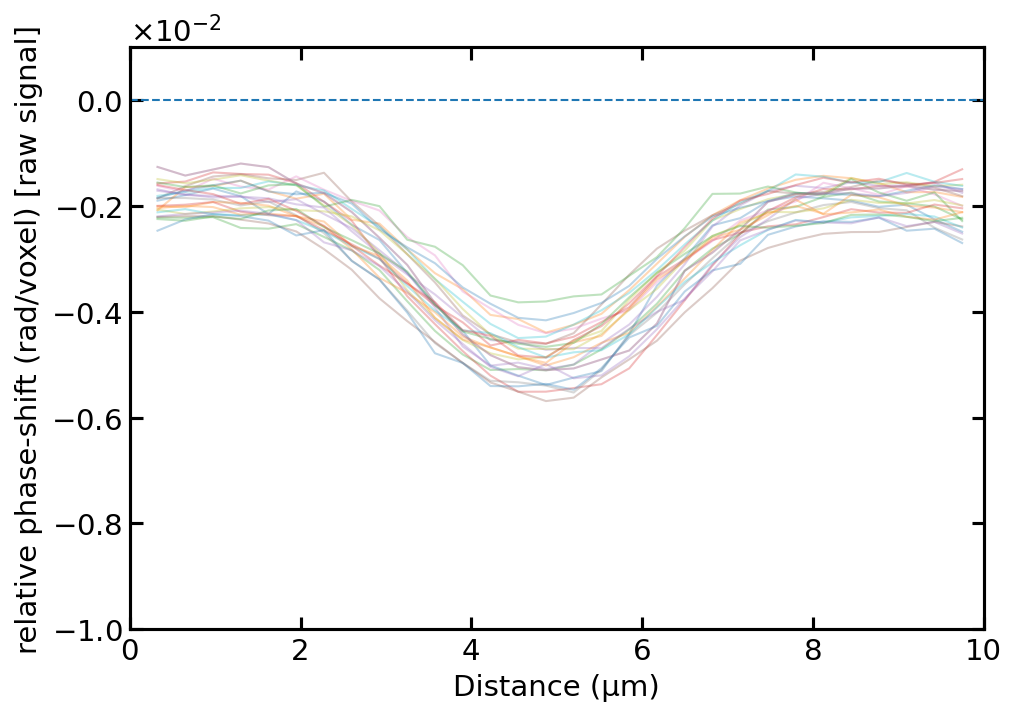

In [39]:
fig, ax = plt.subplots(figsize=(7, 5))
for i in range(profiles.shape[1]):
    ax.plot(dist_um, profiles[:, i], alpha=0.3, linewidth=1)

ax.axhline(0, linestyle='--', linewidth=1)
ax.set_xlabel("Distance (µm)")
ax.set_ylabel("relative phase-shift (rad/voxel) [raw signal]")
ax.set_xlim(0, 10)
ax.set_ylim(-1e-2, 1e-3)
#ax.set_xlim(dist_um.min(), dist_um.max())

# Force scientific notation on y-axis if needed
fmt = ScalarFormatter(useMathText=True)
fmt.set_scientific(True)
fmt.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(fmt)

ax.tick_params(axis='both', length=6, width=1.5)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("P14_raw_profiles.svg", format='svg', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

In [36]:
# Apply baseline correction
corrected_profiles, baseline_means = baseline_correct_profiles(dist_um, profiles)
print(f"Computed baseline means for {profiles.shape[1]} profiles. "
      f"Example (first 5): {baseline_means[:5]}")

Computed baseline means for 25 profiles. Example (first 5): [-0.00198511 -0.00169744 -0.00211067 -0.00152522 -0.00169533]


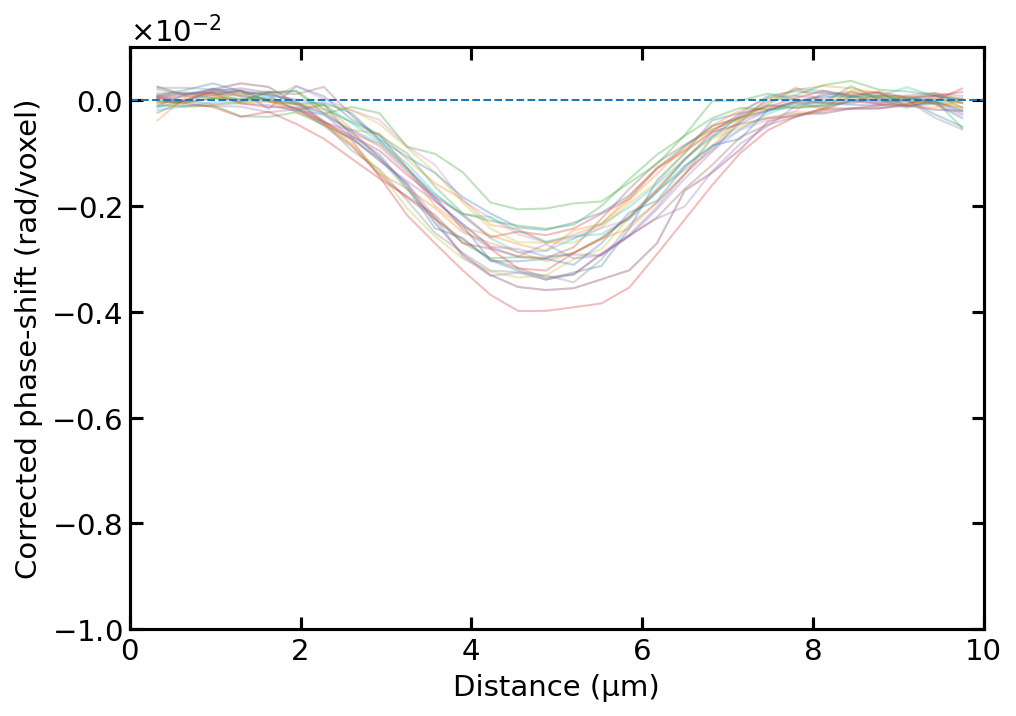

In [37]:
fig, ax = plt.subplots(figsize=(7, 5))
for i in range(corrected_profiles.shape[1]):
    ax.plot(dist_um, corrected_profiles[:, i], alpha=0.3, linewidth=1)

ax.axhline(0, linestyle='--', linewidth=1)
ax.set_xlabel("Distance (µm)")
ax.set_ylabel("Corrected phase-shift (rad/voxel)")
ax.set_xlim(0, 10)
ax.set_ylim(-1e-2, 1e-3)

fmt = ScalarFormatter(useMathText=True)
fmt.set_scientific(True)
fmt.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(fmt)

ax.tick_params(axis='both', length=6, width=1.5)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("P14_corrected_profiles.svg", format='svg', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

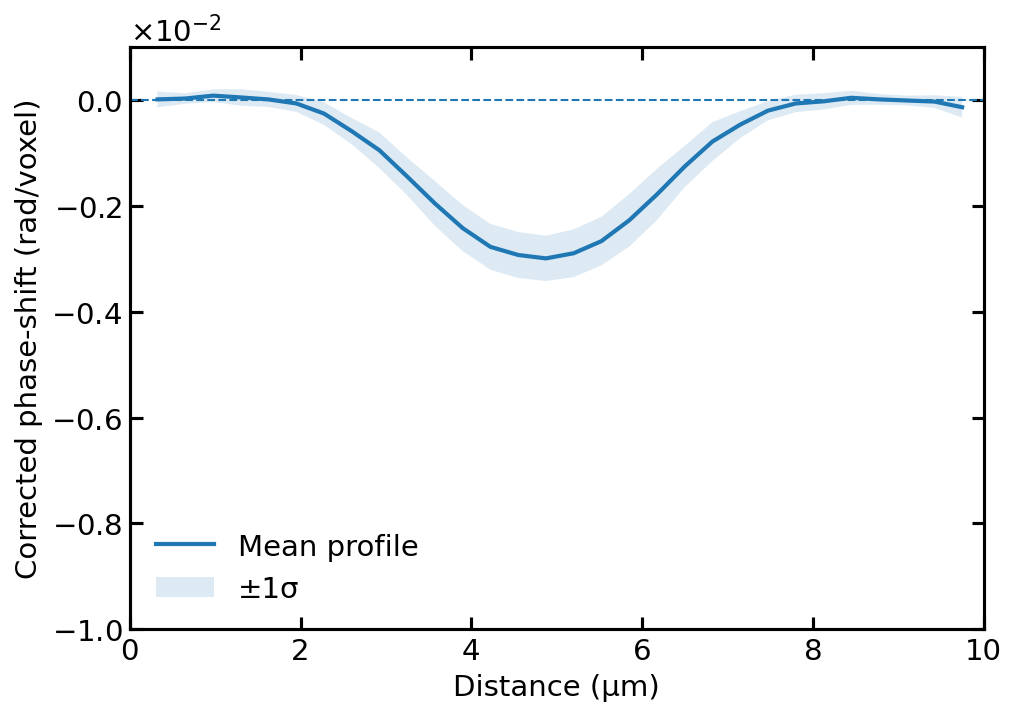

In [40]:
mean_profile, std_profile = compute_avg_and_std(corrected_profiles)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(dist_um, mean_profile, linewidth=2, label='Mean profile')
ax.fill_between(dist_um, mean_profile - std_profile, mean_profile + std_profile,
                alpha=0.15, label='±1σ')

ax.axhline(0, linestyle='--', linewidth=1)
ax.set_xlabel("Distance (µm)")
ax.set_ylabel("Corrected phase-shift (rad/voxel)")
ax.set_xlim(0, 10)
ax.set_ylim(-1e-2, 1e-3)
fmt = ScalarFormatter(useMathText=True)
fmt.set_scientific(True)
fmt.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(fmt)

ax.legend(frameon=False)
ax.tick_params(axis='both', length=6, width=1.5)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("P14_corrected_mean_with_std.svg", format='svg', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

In [ ]:
export_df = pd.DataFrame({
    'Distance (µm)': dist_um,
    'Mean Corrected Profile': mean_profile,
    'Standard Deviation': std_profile
})
out_csv = "P14_averaged_corrected_profile.csv"
export_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")